<a href="https://colab.research.google.com/github/dbright123/Dbot-Advance/blob/main/market_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import MetaTrader5 as mt5
import numpy as np
import pandas as pd

print("MetaTrader5 package author: ",mt5.__author__)
print("MetaTrader5 package version: ",mt5.__version__)

trade_active = mt5.initialize("C:\\Program Files\\HFM MetaTrader 5\\terminal64.exe")

print(trade_active)

if not trade_active:
    print('Initialization failed, check internet connection. You must have Meta Trader 5 installed.')
    mt5.shutdown()

else:
    print(mt5.account_info()._asdict())
    print("\n")
    print(mt5.terminal_info()._asdict())
    print("\n")
    print(mt5.symbols_total())

account = mt5.account_info()
terminal = mt5.terminal_info()

print(account.equity)

if(terminal.connected == True or terminal.trade_allowed == True):
    print("AI is successfully functional")
else:
    print("Please make sure metatrade 5 has internet and algo Trade is Turn On")

MetaTrader5 package author:  MetaQuotes Ltd.
MetaTrader5 package version:  5.0.5200
True
{'login': 102344843, 'trade_mode': 2, 'leverage': 500, 'limit_orders': 150, 'margin_so_mode': 0, 'trade_allowed': True, 'trade_expert': True, 'margin_mode': 2, 'currency_digits': 2, 'fifo_close': False, 'balance': 0.06, 'credit': 0.0, 'profit': 0.0, 'equity': 0.06, 'margin': 0.0, 'margin_free': 0.06, 'margin_level': 0.0, 'margin_so_call': 50.0, 'margin_so_so': 20.0, 'margin_initial': 0.0, 'margin_maintenance': 0.0, 'assets': 0.0, 'liabilities': 0.0, 'commission_blocked': 0.0, 'name': '#Mikky234 - Micheal Omage', 'server': 'HFMarketsGlobal-Live4', 'currency': 'USC', 'company': 'HF Markets (SV) Ltd.'}


{'community_account': False, 'community_connection': False, 'connected': True, 'dlls_allowed': True, 'trade_allowed': True, 'tradeapi_disabled': False, 'email_enabled': False, 'ftp_enabled': False, 'notifications_enabled': False, 'mqid': True, 'build': 5833, 'maxbars': 100000000, 'codepage': 0, 'ping_

In [5]:
import MetaTrader5 as mt5
import pandas as pd

def fetch_rates(symbol, timeframe, count=9_000_000):
    """Pull rates from MT5 and return a tidy DataFrame."""
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, count)
    
    if rates is None:
        raise ValueError(f"MT5 returned None for {symbol}. Error: {mt5.last_error()}")
    
    df = pd.DataFrame(rates)
    
    # ── Debug: show what columns MT5 actually gave us ──────────────────────
    print(f"Available columns: {list(df.columns)}")
    
    # ── Grab volume column whatever it is called ────────────────────────────
    vol_col = next((c for c in df.columns if "volume" in c.lower()), None)
    if vol_col is None:
        raise KeyError(f"No volume column found among: {list(df.columns)}")
    
    df = df[["time", "open", "high", "low", "close", vol_col]].copy()
    df.rename(columns={vol_col: "volume"}, inplace=True)
    #df["time"] = pd.to_datetime(df["time"], unit="s")
    return df.set_index("time")


def build_multi_tf(symbol):
    if not mt5.initialize("C:\\Program Files\\HFM MetaTrader 5\\terminal64.exe"):
        raise RuntimeError(f"MT5 initialize() failed: {mt5.last_error()}")

    try:
        df_1h = fetch_rates(symbol, mt5.TIMEFRAME_H1)
        df_4h = fetch_rates(symbol, mt5.TIMEFRAME_H4)
        df_1d = fetch_rates(symbol, mt5.TIMEFRAME_D1)
    except Exception as e:
        print(f"Error fetching rates: {e}")
    def tag(df, suffix):
        return df.rename(columns={c: f"{c}_{suffix}" for c in df.columns})

    #df_1h = tag(df_1h, "1h").reset_index()
    df_4h = tag(df_4h, "4h").reset_index()
    df_1d = tag(df_1d, "1d").reset_index()

    # Both sides must be sorted for merge_asof
    df_1h = df_1h.sort_values("time")
    df_4h = df_4h.sort_values("time")
    df_1d = df_1d.sort_values("time")

    merged = pd.merge_asof(df_1h, df_4h, on="time", direction="backward")
    merged = pd.merge_asof(merged, df_1d, on="time", direction="backward")

    return merged


# ── Run ────────────────────────────────────────────────────────────────────────
symbol = "XAUUSDc"
df = build_multi_tf(symbol)

out_path = f"Generated{symbol} dbot.csv"
df.to_csv(out_path, index=False)
print(f"\nSaved {len(df):,} rows → {out_path}")
print(df.head())

Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']

Saved 54,951 rows → GeneratedXAUUSDc dbot.csv
         time   open   high    low  close  volume  open_4h  high_4h  low_4h  \
0  1076976000  411.5  417.2  410.1  415.3    5535    411.5    417.2   410.1   
1  1077062400  415.4  417.8  409.4  411.7    6629    415.4    417.8   409.4   
2  1077148800  411.6  413.1  407.6  409.1    6542    411.6    413.1   407.6   
3  1077235200  409.2  412.6  393.8  397.0    6710    409.2    412.6   393.8   
4  1077494400  397.0  401.3  395.5  398.4    5432    397.0    401.3   395.5   

   close_4h  volume_4h  open_1d  high_1d  low_1d  close_1d  volume_1d  
0     415.3       5535    411.5    417.2   410.1     415.3       5535  
1     411.7       6629    415.4   

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings

import joblib
from extra_function import RobustPriceLabelerV3, engineer_features, plot_signals

#warnings.filterwarnings('ignore')

In [2]:


print("="*70)
print("TRADING SIGNAL CLASSIFICATION SYSTEM")
print("="*70)

# Step 1: Load data from Excel
print("\nStep 1: Loading data from Excel file...")
t_symbol = ["XAUUSD","#BTCUSD","GBPUSD","Volatility 100 (1s) Index","Step Index"] #GPBUSD is 1 hour and XAUUSD is 15 min data
n = 0
m_label = "Generated"+t_symbol[n]






TRADING SIGNAL CLASSIFICATION SYSTEM

Step 1: Loading data from Excel file...


In [3]:

df = pd.read_csv(m_label+ " dbot.csv")
df = engineer_features(df[:-200])


e:\GitHub\Dbot-Advance\extra_function.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time'] = pd.to_datetime(df['time'], unit='s', errors='coerce')
e:\GitHub\Dbot-Advance\extra_function.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['time'].dt.month
e:\GitHub\Dbot-Advance\extra_function.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

In [4]:
df

,open,high,low,close,volume,open_4h,high_4h,low_4h,close_4h,volume_4h,open_1d,high_1d,low_1d,close_1d,volume_1d,month,day,hour,day_of_week
0,384.00,384.30,383.30,383.80,47,384.00,384.30,383.30,383.80,47,384.00,384.80,382.80,384.10,303,6,11,7,4
1,383.80,384.30,383.10,383.10,44,383.80,384.30,382.80,383.60,170,384.00,384.80,382.80,384.10,303,6,11,8,4
2,383.10,384.10,382.80,383.10,57,383.80,384.30,382.80,383.60,170,384.00,384.80,382.80,384.10,303,6,11,9,4
3,383.00,383.80,383.00,383.60,40,383.80,384.30,382.80,383.60,170,384.00,384.80,382.80,384.10,303,6,11,10,4
4,383.60,383.80,383.50,383.60,29,383.80,384.30,382.80,383.60,170,384.00,384.80,382.80,384.10,303,6,11,11,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127896,4288.76,4301.89,4273.03,4294.34,21837,4288.76,4339.46,4273.03,4333.08,91123,4326.33,4353.38,4268.51,4326.66,504297,6,8,12,0
127897,4294.34,4305.61,4286.15,4302.03,19315,4288.76,4339.46,4273.03,4333.08,91123,4326.33,4353.38,4268.51,4326.66,504297,6,8,13,0
127898,4302.03,4333.30,4297.16,4331.22,24653,4288.76,4339.46,4273.03,4333.08,91123,4326.33,4353.38,4268.51,4326.66,504297,6,8,14,0
127899,4331.24,4339.46,4320.21,4333.08,25318,4288.76,4339.46,4273.03,4333.08,91123,4326.33,4353.38,4268.51,4326.66,504297,6,8,15,0


In [5]:

from extra_function import fix_pivot_labels


labeler = RobustPriceLabelerV3(
                atr_period      = 14,
                zigzag_atr_mult = 0.5,
                hold_bars       = 1,
                min_streak      = 0.01,
                target_hold_pct = 0.01 )


df = labeler.label(df)
print(df[["close", "label", "label_name", "label_conf"]].tail(20))

#df = fix_pivot_labels(df)
#df.to_csv("Generated gold"+" dbot.csv", index=False)
"""
from extra_function import RobustPriceLabelerV4, RobustPriceLabelerV5


labeler = RobustPriceLabelerV4(
    # ----- Core zigzag -----
    atr_period       = 14,
    zigzag_atr_mult  = 0.5,
    hold_bars        = 2,
    min_streak       = 2,
    target_hold_pct  = 0.30,
    # ----- S/R zone filter (backward) -----
    sr_lookback      = 3,       # track last 3 swing H and 3 swing L
    zone_mult        = 1.0,     # block within 1 ATR of any S/R level
    # ----- Triple barrier (forward) -----
    profit_mult      = 1.0,     # TP = entry +/- 1.5 x ATR
    stop_mult        = 1.0,     # SL = entry -/+ 1.0 x ATR
    max_confirm_bars = 10,      # look up to 20 bars (100 min) ahead
    # ----- Optional EMA momentum gate -----
    use_momentum_gate= False,   # set True for stricter trend-aligned labels
    ema_fast         = 8,
    ema_slow         = 21,
    ema_slope_tol    = 0.5,
)

df = labeler.label(df)
print(
    df[["close", "label", "label_name", "label_conf",
            "zone_locked", "barrier_locked"]].tail(20).to_string()
)

from extra_function import RobustPriceLabelerV4, RobustPriceLabelerV5
labeler = RobustPriceLabelerV5(
    # Core zigzag
    atr_period       = 14,
    zigzag_atr_mult  = 0.5,
    # S/R zone filter (backward)
    sr_lookback      = 3,       # track last 3 swing highs and 3 swing lows
    zone_mult        = 1.0,     # flip within 1 ATR of any S/R level
    # Triple-barrier (forward)
    profit_mult      = 1.5,     # TP = entry +/- 1.5 x ATR
    stop_mult        = 1.0,     # SL = entry -/+ 1.0 x ATR
    max_confirm_bars = 20,      # 20 bars forward = 100 min on 5-min chart
    # EMA momentum gate (optional)
    use_momentum_gate= True,   # set True for trend-aligned labeling
    ema_fast         = 8,
    ema_slow         = 21,
    ema_slope_tol    = 0.5,
)

df = labeler.label(df)

print(
    df[[
        "close", "label", "label_name", "label_conf",
        "zone_flipped", "barrier_flipped", "any_flipped", "partial_forward"
    ]].tail(20).to_string()
)

# Verify no HOLDs exist
assert df["label"].isin([1, 2]).all(), "ERROR: HOLD labels found!"
print("\nValidation passed: all labels are binary (1=buy, 2=sell)")
 """

Computing ATR...
Finding zigzag pivots...
   56311 pivots found
Assigning zone labels...
Enforcing class balance...
Computing confidence scores...

── Label Distribution ──────────────────────────
  buy : 43,467  ( 34.0%)  █████████████
  sell: 40,745  ( 31.9%)  ████████████
  hold: 43,689  ( 34.2%)  █████████████
────────────────────────────────────────────────
          close  label label_name  label_conf
127881  4344.66      2       sell       0.488
127882  4341.78      2       sell       0.514
127883  4322.42      2       sell       0.638
127884  4318.52      2       sell       0.508
127885  4317.25      2       sell       0.421
127886  4343.96      2       sell       0.271
127887  4342.17      2       sell       0.342
127888  4325.45      2       sell       0.528
127889  4310.61      2       sell       0.523
127890  4316.98      2       sell       0.258
127891  4312.66      2       sell       0.347
127892  4292.03      2       sell       0.614
127893  4299.89      2       sell    

'\nfrom extra_function import RobustPriceLabelerV4, RobustPriceLabelerV5\n\n\nlabeler = RobustPriceLabelerV4(\n    # ----- Core zigzag -----\n    atr_period       = 14,\n    zigzag_atr_mult  = 0.5,\n    hold_bars        = 2,\n    min_streak       = 2,\n    target_hold_pct  = 0.30,\n    # ----- S/R zone filter (backward) -----\n    sr_lookback      = 3,       # track last 3 swing H and 3 swing L\n    zone_mult        = 1.0,     # block within 1 ATR of any S/R level\n    # ----- Triple barrier (forward) -----\n    profit_mult      = 1.0,     # TP = entry +/- 1.5 x ATR\n    stop_mult        = 1.0,     # SL = entry -/+ 1.0 x ATR\n    max_confirm_bars = 10,      # look up to 20 bars (100 min) ahead\n    # ----- Optional EMA momentum gate -----\n    use_momentum_gate= False,   # set True for stricter trend-aligned labels\n    ema_fast         = 8,\n    ema_slow         = 21,\n    ema_slope_tol    = 0.5,\n)\n\ndf = labeler.label(df)\nprint(\n    df[["close", "label", "label_name", "label_conf

In [6]:


"""Analyze the labeling results"""
print(f"Total samples: {len(df)}")
print(f"Buy labels: {(df['label'] == 1).sum()} ({((df['label'] == 1).sum()/len(df))*100:.1f}%)")
print(f"Sell labels: {(df['label'] == 2).sum()} ({((df['label'] == 2).sum()/len(df))*100:.1f}%)")
print(f"Hold labels: {(df['label'] == 0).sum()} ({((df['label'] == 0).sum()/len(df))*100:.1f}%)")



Total samples: 127901
Buy labels: 43467 (34.0%)
Sell labels: 40745 (31.9%)
Hold labels: 43689 (34.2%)



Step 5: Visualizing trading signals...


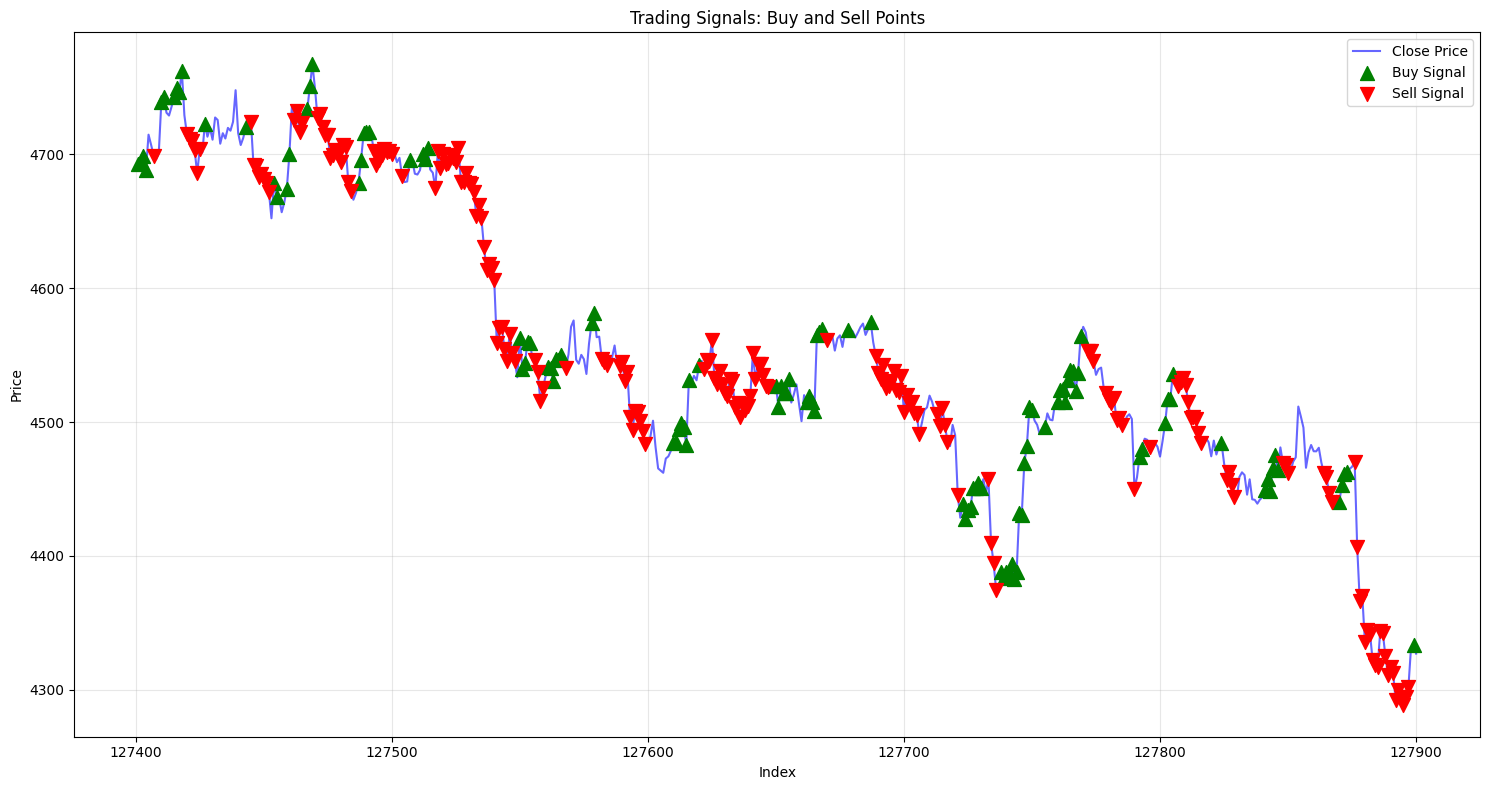


Signal Distribution:
Hold/No Action (0): 183
Buy Signals (1): 114
Sell Signals (2): 203


In [7]:

# Step 5: Visualize signals
print("\nStep 5: Visualizing trading signals...")
plot_signals(df[-500:])



In [8]:
print(f"Data loaded: {len(df)} rows")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Data loaded: 127901 rows
Memory usage: 25.45 MB


In [9]:
df

,open,high,low,close,volume,open_4h,high_4h,low_4h,close_4h,volume_4h,...,low_1d,close_1d,volume_1d,month,day,hour,day_of_week,label,label_name,label_conf
0,384.00,384.30,383.30,383.80,47,384.00,384.30,383.30,383.80,47,...,382.80,384.10,303,6,11,7,4,0,hold,0.369
1,383.80,384.30,383.10,383.10,44,383.80,384.30,382.80,383.60,170,...,382.80,384.10,303,6,11,8,4,0,hold,0.603
2,383.10,384.10,382.80,383.10,57,383.80,384.30,382.80,383.60,170,...,382.80,384.10,303,6,11,9,4,0,hold,0.428
3,383.00,383.80,383.00,383.60,40,383.80,384.30,382.80,383.60,170,...,382.80,384.10,303,6,11,10,4,0,hold,0.428
4,383.60,383.80,383.50,383.60,29,383.80,384.30,382.80,383.60,170,...,382.80,384.10,303,6,11,11,4,1,buy,0.304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127896,4288.76,4301.89,4273.03,4294.34,21837,4288.76,4339.46,4273.03,4333.08,91123,...,4268.51,4326.66,504297,6,8,12,0,2,sell,0.420
127897,4294.34,4305.61,4286.15,4302.03,19315,4288.76,4339.46,4273.03,4333.08,91123,...,4268.51,4326.66,504297,6,8,13,0,2,sell,0.449
127898,4302.03,4333.30,4297.16,4331.22,24653,4288.76,4339.46,4273.03,4333.08,91123,...,4268.51,4326.66,504297,6,8,14,0,0,hold,0.525
127899,4331.24,4339.46,4320.21,4333.08,25318,4288.76,4339.46,4273.03,4333.08,91123,...,4268.51,4326.66,504297,6,8,15,0,1,buy,0.581


In [10]:
# Prepare features and labels

feature_cols = ['open', 'high', 'low', 'close', 'volume',"open_4h","high_4h","low_4h","close_4h","volume_4h","open_1d","high_1d","low_1d","close_1d","volume_1d",
                'hour', 'day', 'month','day_of_week']
                
X = df[feature_cols].values
y = df['label'].values
#df = None
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X , y = None, None



In [11]:
print("Before:", y_train.shape)
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train, y_train = rus.fit_resample(X_train, y_train)

print("After: ", y_train.shape)

Before: (115110,)
After:  (110010,)


In [12]:
print(X_train.shape)

(110010, 19)


In [13]:
print("\n" + "="*70)
print("TRAINING CLASSIFICATION MODELS")
print("="*70)
model = RandomForestClassifier(n_estimators=350, n_jobs=2, random_state=42,class_weight='balanced', verbose=1)
# Train
model.fit(X_train, y_train)
#X_train, y_train = None, None
# Predict
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")


TRAINING CLASSIFICATION MODELS


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:   23.6s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:  1.7min
[Parallel(n_jobs=2)]: Done 350 out of 350 | elapsed:  3.0min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.9s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    4.9s
[Parallel(n_jobs=2)]: Done 350 out of 350 | elapsed:    6.9s finished


Accuracy: 0.7316

Confusion Matrix:
[[2787  747  835]
 [ 876 3371  100]
 [ 798   77 3200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63      4369
           1       0.80      0.78      0.79      4347
           2       0.77      0.79      0.78      4075

    accuracy                           0.73     12791
   macro avg       0.73      0.73      0.73     12791
weighted avg       0.73      0.73      0.73     12791



In [14]:
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def predict_and_plot_signals(model, df, feature_columns,
                             ohlc_map=None,
                             chart_style='charles'):
    """
    Predicts buy/sell signals and plots them on an OHLC candlestick chart.

    Parameters
    ----------
    model : trained classifier with a `predict` method
    df : pandas.DataFrame
        Must contain OHLC columns (default names: 'open','high','low','close')
        and all columns listed in feature_columns.
    feature_columns : list of str
        Columns used as features for the model.
    ohlc_map : dict, optional
        Maps standard OHLC names to actual df column names.
        Default: {'Open':'open','High':'high','Low':'low','Close':'close'}
    chart_style : str, default 'charles'
        mplfinance style (e.g., 'charles', 'yahoo', 'binance', 'default').
    """
    # --- 0. Work on a copy to avoid side effects ---
    data = df.copy()

    # --- 1. Ensure DatetimeIndex ---
    if not pd.api.types.is_datetime64_any_dtype(data.index):
        try:
            data.index = pd.to_datetime(data.index)
        except Exception as e:
            raise ValueError("Could not convert DataFrame index to DatetimeIndex. "
                             "Please provide a DataFrame with a datetime-like index.") from e

    # --- 2. Map OHLC columns ---
    if ohlc_map is None:
        ohlc_map = {'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close'}

    for col in ohlc_map.values():
        if col not in data.columns:
            raise KeyError(f"Required OHLC column '{col}' not found in DataFrame.")

    ohlc_df = data[[ohlc_map['Open'], ohlc_map['High'],
                    ohlc_map['Low'], ohlc_map['Close']]].copy()
    ohlc_df.columns = ['Open', 'High', 'Low', 'Close']
    # Keep the (now datetime) index from data

    # --- 3. Make predictions ---
    X = data[feature_columns].values
    data['predicted_label'] = model.predict(X)

    # --- 4. Build marker Series with the SAME index as ohlc_df ---
    buy_marker = pd.Series(index=ohlc_df.index, dtype=float, name='buy')
    sell_marker = pd.Series(index=ohlc_df.index, dtype=float, name='sell')

    buys = data[data['predicted_label'] == 1]
    if not buys.empty:
        buy_marker.loc[buys.index] = buys[ohlc_map['Low']]

    sells = data[data['predicted_label'] == 2]
    if not sells.empty:
        sell_marker.loc[sells.index] = sells[ohlc_map['High']]

    # --- 5. Create addplots ---
    apds = []
    if not buys.empty:
        apds.append(mpf.make_addplot(buy_marker, type='scatter', marker='^',
                                     color='green', markersize=100))
    if not sells.empty:
        apds.append(mpf.make_addplot(sell_marker, type='scatter', marker='v',
                                     color='red', markersize=100))

    # --- 6. Plot ---
    fig, axlist = mpf.plot(ohlc_df,
                           type='candle',
                           style=chart_style,
                           title='Market Predictions: Buy/Sell Signals on Candlestick Chart',
                           ylabel='Price',
                           addplot=apds if apds else None,
                           returnfig=True,
                           figsize=(16, 8),
                           volume=False,
                           warn_too_much_data=len(data) + 50)

    # --- 7. Legend (mplfinance doesn't auto-add for addplots) ---
    legend_elements = [
        Line2D([0], [0], marker='^', color='w', markerfacecolor='green',
               markersize=12, label='Predicted BUY'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor='red',
               markersize=12, label='Predicted SELL')
    ]
    axlist[0].legend(handles=legend_elements, loc='best')
    plt.tight_layout()
    plt.show()

    # --- 8. Print distribution ---
    print("\nSignal Distribution:")
    print(f"Hold / No Action (0): {len(data[data['predicted_label'] == 0])}")
    print(f"Buy Signals      (1): {len(data[data['predicted_label'] == 1])}")
    print(f"Sell Signals     (2): {len(data[data['predicted_label'] == 2])}")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 350 out of 350 | elapsed:    0.0s finished
C:\Users\dbright\AppData\Local\Temp\ipykernel_28432\4127393977.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


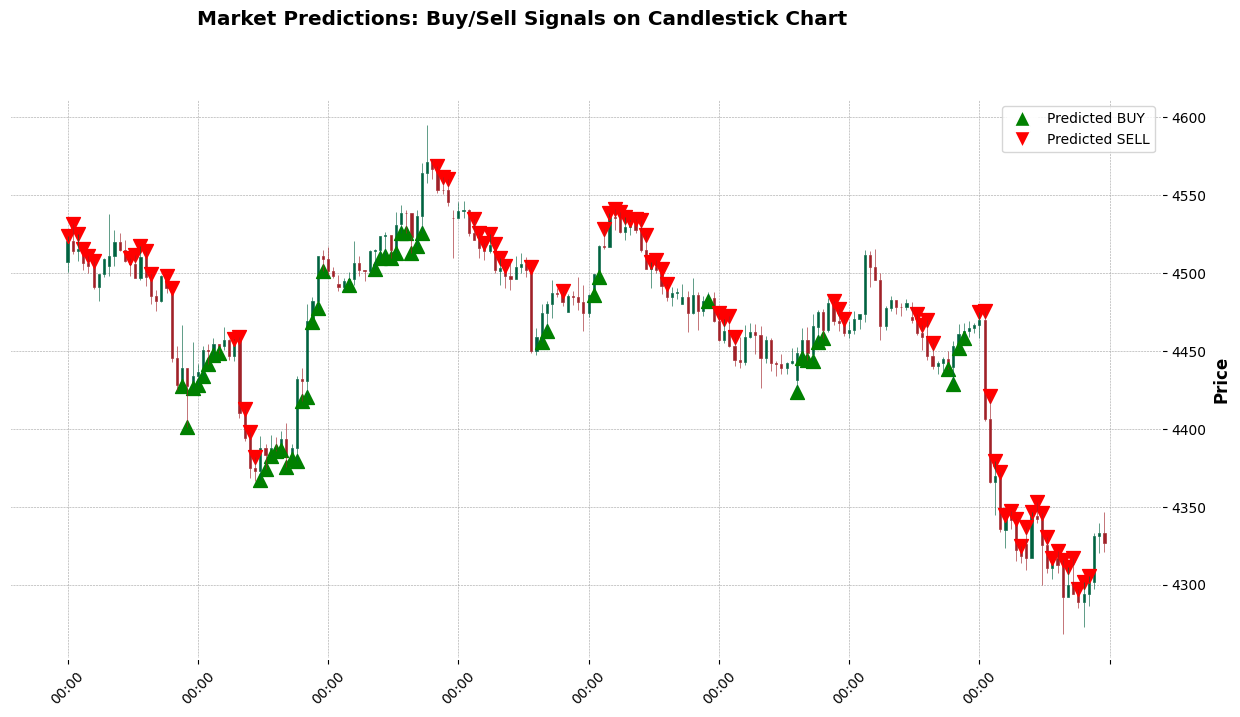


Signal Distribution:
Hold / No Action (0): 77
Buy Signals      (1): 47
Sell Signals     (2): 76


In [15]:

# --- Example Usage ---
# Ensure your 'df' has gone through engineer_features() first
# features = ['open', 'high', 'low', 'volume', 'month', 'day', 'hour', 'minute', 'day_of_week']
#ohlc_map = {'Open':'Open', 'High':'High', 'Low':'Low', 'Close':'Close'}
predict_and_plot_signals(model, df[-200:], feature_cols)